# Radial divergence-current test

This notebook tests whether single-particle trajectories contain evidence for a **radial probability current**, as expected for a source–sink process that breaks detailed balance.

For every trajectory, the first observed localization is treated as a **birth** and the last observed localization as a **death**. Distances are measured from the robust cell centre and normalized by the median localization radius. The scalar statistic is

$$
\delta = \langle r_{\mathrm{birth}}\rangle - \langle r_{\mathrm{death}}\rangle.
$$

At equilibrium, births and deaths are identically distributed and therefore $\delta\approx0$. A non-equilibrium radial source–sink process can shift the two distributions. We additionally retain the full radial profile

$$
I(r)=F_{\mathrm{birth}}(r)-F_{\mathrm{death}}(r),
$$

which resolves where the birth/death imbalance occurs rather than reducing it to one mean-distance difference.

The workflow first validates the estimators on simulations, then applies exactly the same estimators to the five experimental conditions used in the publication.


## Reproducibility and expected repository layout

Run the notebook from the repository root:

```text
repository/
├── analysis_AllData.py
├── divergence_test.ipynb
├── biophysical_journal.mplstyle      # optional
└── AllData/
    ├── Rad52/Cell*.txt
    ├── TwoDSB/Cell*.txt
    ├── SUMO/Cell*.txt
    ├── Rad51/Cell*.txt
    └── Rfa1/Cell*.txt
```

Trajectory files are whitespace-separated with columns `trajectory_id, x, y, time` (coordinates in µm and time in s). Additional columns are ignored.

**Rad51 segmentation.** The configuration below applies `segment_foci()` to Rad51 files, matching the main publication analysis. If the Rad51 files already contain exactly one independently analysed focus each, set `SEGMENT_DATASETS = set()` before running the notebook.

Simulation seeds are fixed so calibration results are reproducible.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from numba import njit
from scipy import stats

from analysis_AllData import MIN_TOTAL, segment_foci

# Optional journal-specific plotting style.
STYLE_FILE = Path("biophysical_journal.mplstyle")
if STYLE_FILE.exists():
    plt.style.use(STYLE_FILE)

SEED = 0
DATA_ROOT = (Path.cwd() / "AllData").resolve()

# condition -> (subdirectory, filename pattern, frame interval [s])
DATASETS = {
    "Rad52": ("Rad52", "Cell*.txt", 0.02),
    "TwoDSB": ("TwoDSB", "Cell*.txt", 0.02),
    "SUMO": ("SUMO", "Cell*.txt", 0.02),
    "Rad51": ("Rad51", "Cell*.txt", 0.03),
    "Rfa1": ("Rfa1", "Cell*.txt", 0.02),
}

SEGMENT_DATASETS = {"Rad51"}
PRETTY_NAMES = {
    "Rad52": "Rad52 (1 DSB)",
    "TwoDSB": "Rad52 (2 DSB)",
    "SUMO": "Rad52-SUMO",
    "Rad51": "Rad51",
    "Rfa1": "Rfa1",
}


MIN_TRACKS = 5
RGRID = np.linspace(0.0, 3.0, 61)  # normalized radius r / median(r)


## 1. Simulation models

Three controls are used.

1. **Ornstein–Uhlenbeck trap:** a simple equilibrium process or a transient condition in which tracks are preferentially initiated near the centre.
2. **Equilibrium condensate:** overdamped diffusion in a radial sigmoidal potential, initialized from its Boltzmann distribution. This is the primary equilibrium null.
3. **Steady source–sink condensate:** a fraction `pump` of trajectories is initialized in the condensate interior and terminated when it reaches an outer sink radius. This continuously biases trajectory starts and ends and therefore provides a positive control for radial divergence.

Localization noise is added only after the latent trajectories have been simulated.


In [2]:
@njit
def _simulate_ou_nb(source, n_tracks, D, k, dt, frame_interval, sigma, seed):
    """Numba implementation of the 2D Ornstein-Uhlenbeck calibration model."""
    np.random.seed(seed)
    stationary_sd = np.sqrt(D / k)
    noise_amplitude = np.sqrt(2 * D * dt)
    output = np.empty((n_tracks * 50, 4))
    row = 0

    for trajectory_id in range(n_tracks):
        length = np.random.randint(5, 50)
        initial_sd = 0.2 * stationary_sd if source else stationary_sd
        x = np.random.normal() * initial_sd
        y = np.random.normal() * initial_sd

        xs = np.empty(length)
        ys = np.empty(length)
        times = np.empty(length)
        xs[0], ys[0], times[0] = x, y, 0.0
        t = 0.0
        frame = 1
        n = 1

        while n < length:
            x += -k * x * dt + noise_amplitude * np.random.normal()
            y += -k * y * dt + noise_amplitude * np.random.normal()
            t += dt
            if t > frame * frame_interval:
                xs[n], ys[n], times[n] = x, y, t
                frame += 1
                n += 1

        for i in range(length):
            output[row, 0] = trajectory_id
            output[row, 1] = xs[i] + np.random.normal() * sigma
            output[row, 2] = ys[i] + np.random.normal() * sigma
            output[row, 3] = times[i]
            row += 1

    return output[:row]


def simulate_ou(
    mode,
    n_tracks=50,
    D=0.05,
    k=5.0,
    dt=0.001,
    frame_interval=0.02,
    sigma=0.025,
    seed=SEED,
):
    """Simulate equilibrium or centre-initiated OU trajectories."""
    if mode not in {"eq", "source"}:
        raise ValueError("mode must be 'eq' or 'source'")
    return _simulate_ou_nb(
        mode == "source", n_tracks, D, k, dt, frame_interval, sigma, seed
    )


In [3]:
@njit
def _simulate_condensate_nb(
    uniform,
    n_tracks,
    D,
    dt,
    frame_interval,
    sigma,
    focus_radius,
    potential_depth,
    beta,
    nucleus_radius,
    seed,
):
    """Numba implementation of equilibrium/transient condensate trajectories."""
    np.random.seed(seed)
    noise_amplitude = np.sqrt(2 * D * dt)
    output = np.empty((n_tracks * 50, 4))
    row = 0

    for trajectory_id in range(n_tracks):
        length = np.random.randint(10, 50)

        while True:
            radius = nucleus_radius * np.sqrt(np.random.random())
            theta = 2 * np.pi * np.random.random()
            x = radius * np.cos(theta)
            y = radius * np.sin(theta)
            if uniform:
                break
            switch = 1.0 / (1.0 + np.exp(-beta * (radius - focus_radius)))
            if np.random.random() < np.exp(-potential_depth * switch):
                break

        xs = np.empty(length)
        ys = np.empty(length)
        times = np.empty(length)
        xs[0], ys[0], times[0] = x, y, 0.0
        t = 0.0
        frame = 1
        n = 1

        while n < length:
            radius = np.sqrt(x * x + y * y) + 1e-12
            switch = 1.0 / (1.0 + np.exp(-beta * (radius - focus_radius)))
            radial_drift = -D * potential_depth * beta * switch * (1.0 - switch)
            dx = radial_drift * (x / radius) * dt + noise_amplitude * np.random.normal()
            dy = radial_drift * (y / radius) * dt + noise_amplitude * np.random.normal()
            x += dx
            y += dy

            if np.sqrt(x * x + y * y) > nucleus_radius:
                x -= dx
                y -= dy

            t += dt
            if t > frame * frame_interval:
                xs[n], ys[n], times[n] = x, y, t
                frame += 1
                n += 1

        for i in range(length):
            output[row, 0] = trajectory_id
            output[row, 1] = xs[i] + np.random.normal() * sigma
            output[row, 2] = ys[i] + np.random.normal() * sigma
            output[row, 3] = times[i]
            row += 1

    return output[:row]


def simulate_condensate(
    mode,
    n_tracks=30,
    D=0.1,
    dt=1e-4,
    frame_interval=0.02,
    sigma=0.025,
    focus_radius=0.2,
    potential_depth=3.0,
    beta=200.0,
    nucleus_radius=0.5,
    seed=SEED,
):
    """Simulate a radial condensate under equilibrium or uniform initialization."""
    if mode not in {"eq", "uniform"}:
        raise ValueError("mode must be 'eq' or 'uniform'")
    return _simulate_condensate_nb(
        mode == "uniform",
        n_tracks,
        D,
        dt,
        frame_interval,
        sigma,
        focus_radius,
        potential_depth,
        beta,
        nucleus_radius,
        seed,
    )


In [4]:
@njit
def _simulate_source_sink_nb(
    pump,
    n_tracks,
    D,
    dt,
    frame_interval,
    sigma,
    focus_radius,
    potential_depth,
    beta,
    nucleus_radius,
    sink_radius,
    seed,
):
    """Numba implementation of the steady source-sink positive control."""
    np.random.seed(seed)
    noise_amplitude = np.sqrt(2 * D * dt)
    output = np.empty((n_tracks * 50, 4))
    row = 0
    inner_birth_radius = 0.05

    for trajectory_id in range(n_tracks):
        max_length = np.random.randint(10, 50)
        pumped = np.random.random() < pump

        if pumped:
            radius = np.sqrt(
                inner_birth_radius**2
                + (focus_radius**2 - inner_birth_radius**2) * np.random.random()
            )
            theta = 2 * np.pi * np.random.random()
            x = radius * np.cos(theta)
            y = radius * np.sin(theta)
        else:
            while True:
                radius = nucleus_radius * np.sqrt(np.random.random())
                theta = 2 * np.pi * np.random.random()
                x = radius * np.cos(theta)
                y = radius * np.sin(theta)
                switch = 1.0 / (1.0 + np.exp(-beta * (radius - focus_radius)))
                if np.random.random() < np.exp(-potential_depth * switch):
                    break

        xs = np.empty(max_length)
        ys = np.empty(max_length)
        times = np.empty(max_length)
        xs[0], ys[0], times[0] = x, y, 0.0
        t = 0.0
        frame = 1
        n = 1

        while n < max_length:
            radius = np.sqrt(x * x + y * y) + 1e-12
            switch = 1.0 / (1.0 + np.exp(-beta * (radius - focus_radius)))
            radial_drift = -D * potential_depth * beta * switch * (1.0 - switch)
            dx = radial_drift * (x / radius) * dt + noise_amplitude * np.random.normal()
            dy = radial_drift * (y / radius) * dt + noise_amplitude * np.random.normal()
            x += dx
            y += dy

            if np.sqrt(x * x + y * y) > nucleus_radius:
                x -= dx
                y -= dy

            t += dt
            if t > frame * frame_interval:
                xs[n], ys[n], times[n] = x, y, t
                frame += 1
                n += 1
                if pumped and np.sqrt(x * x + y * y) >= sink_radius:
                    break

        for i in range(n):
            output[row, 0] = trajectory_id
            output[row, 1] = xs[i] + np.random.normal() * sigma
            output[row, 2] = ys[i] + np.random.normal() * sigma
            output[row, 3] = times[i]
            row += 1

    return output[:row]


def simulate_source_sink(
    pump,
    n_tracks=50,
    D=0.1,
    dt=1e-4,
    frame_interval=0.02,
    sigma=0.025,
    focus_radius=0.2,
    potential_depth=3.0,
    beta=200.0,
    nucleus_radius=0.5,
    sink_radius=0.45,
    seed=SEED,
):
    """Simulate the radial source-sink positive control.

    ``pump=0`` recovers the equilibrium null. For ``pump>0``, pumped tracks
    are born inside the focus and terminate when they reach ``sink_radius``.
    """
    if not 0.0 <= pump <= 1.0:
        raise ValueError("pump must lie between 0 and 1")
    return _simulate_source_sink_nb(
        pump,
        n_tracks,
        D,
        dt,
        frame_interval,
        sigma,
        focus_radius,
        potential_depth,
        beta,
        nucleus_radius,
        sink_radius,
        seed,
    )


## 2. Radial-current estimators

The centre is estimated by the coordinate-wise median of all localizations in the cell. All radii are divided by the median localization radius so cells with different spatial scales can be compared.

`birth_death_delta()` returns the difference between mean normalized birth and death radii. The accompanying two-sample KS p-value is retained as a descriptive comparison of the two radial distributions; the publication-level condition test below is instead performed across independently analysed cells.

`flux_profile()` evaluates the difference between the empirical birth and death CDFs on a common normalized radial grid. Because its sign follows `F_birth - F_death`, interpretation should always be made together with the simulation controls rather than from sign alone.


In [5]:
def _birth_death_radii(data, min_len=2):
    """Return normalized birth/death radii for one cell or ``(None, None)``."""
    if data is None or len(data) == 0:
        return None, None

    center_x = np.median(data[:, 1])
    center_y = np.median(data[:, 2])
    all_radii = np.hypot(data[:, 1] - center_x, data[:, 2] - center_y)
    scale = np.median(all_radii)
    if not np.isfinite(scale) or scale <= 0:
        return None, None

    birth_radii = []
    death_radii = []
    for trajectory_id in np.unique(data[:, 0]):
        trajectory = data[data[:, 0] == trajectory_id]
        trajectory = trajectory[np.argsort(trajectory[:, 3])]
        if len(trajectory) < min_len:
            continue
        birth_radii.append(
            np.hypot(trajectory[0, 1] - center_x, trajectory[0, 2] - center_y)
        )
        death_radii.append(
            np.hypot(trajectory[-1, 1] - center_x, trajectory[-1, 2] - center_y)
        )

    if len(birth_radii) < MIN_TRACKS:
        return None, None

    return np.asarray(birth_radii) / scale, np.asarray(death_radii) / scale


def birth_death_delta(data, min_len=2):
    """Calculate normalized mean birth-minus-death radius for one cell.

    Returns
    -------
    delta : float
        ``mean(r_birth) - mean(r_death)``.
    ks_pvalue : float
        Two-sample KS p-value comparing birth and death radius distributions.
    n_tracks : int
        Number of trajectories contributing to the estimator.
    """
    birth_radii, death_radii = _birth_death_radii(data, min_len=min_len)
    if birth_radii is None:
        return np.nan, np.nan, 0

    delta = float(np.mean(birth_radii) - np.mean(death_radii))
    ks_pvalue = float(stats.ks_2samp(birth_radii, death_radii).pvalue)
    return delta, ks_pvalue, len(birth_radii)


def flux_profile(data, min_len=2, radius_grid=RGRID):
    """Return ``F_birth(r) - F_death(r)`` on a normalized radial grid."""
    birth_radii, death_radii = _birth_death_radii(data, min_len=min_len)
    if birth_radii is None:
        return np.full(len(radius_grid), np.nan)

    F_birth = np.array([np.mean(birth_radii <= radius) for radius in radius_grid])
    F_death = np.array([np.mean(death_radii <= radius) for radius in radius_grid])
    return F_birth - F_death


## 3. Calibration on simulated controls

The equilibrium condensate defines the null distribution used later for the experimental data. A uniformly initialized condensate is included only as a **transient non-equilibrium control**; it is not a steady source–sink process. The steady positive control is `simulate_source_sink()`.

The first plot compares the scalar $\delta$ distributions. The second shows the radial CDF-difference profiles. Finally, a pump-strength sweep demonstrates how estimator magnitude changes as the source–sink drive is increased.


/var/folders/kp/rpw6x9gx71ncgf2hj3y5qc080000gn/T/ipykernel_22010/2511478166.py:28: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


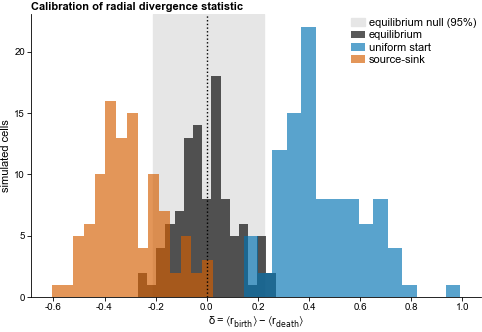

/var/folders/kp/rpw6x9gx71ncgf2hj3y5qc080000gn/T/ipykernel_22010/2511478166.py:46: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


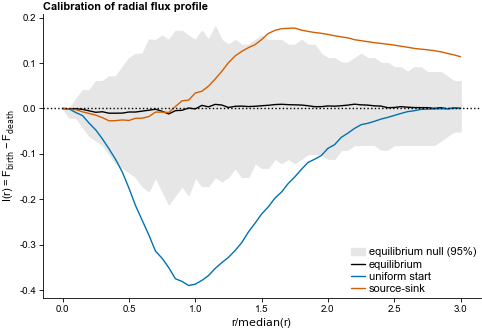

In [6]:
N_CALIBRATION = 100

calibration_delta = np.zeros((N_CALIBRATION, 3))
calibration_profiles = np.zeros((N_CALIBRATION, len(RGRID), 3))

for seed in range(N_CALIBRATION):
    equilibrium = simulate_source_sink(0.0, seed=seed)
    transient = simulate_condensate("uniform", seed=seed)
    source_sink = simulate_source_sink(1.0, seed=seed)

    for j, data in enumerate((equilibrium, transient, source_sink)):
        calibration_delta[seed, j] = birth_death_delta(data)[0]
        calibration_profiles[seed, :, j] = flux_profile(data)

eq_delta, transient_delta, source_sink_delta = calibration_delta.T
null_delta_band = np.nanpercentile(eq_delta, [2.5, 97.5])

fig, ax = plt.subplots(figsize=(5.0, 3.5))
ax.axvspan(*null_delta_band, color="0.9", label="equilibrium null (95%)")
ax.axvline(0, color="k", ls=":")
ax.hist(eq_delta, bins=15, alpha=0.65, label="equilibrium")
ax.hist(transient_delta, bins=15, alpha=0.65, label="uniform start")
ax.hist(source_sink_delta, bins=15, alpha=0.65, label="source-sink")
ax.set_xlabel(r"$\delta=\langle r_\mathrm{birth}\rangle-\langle r_\mathrm{death}\rangle$")
ax.set_ylabel("simulated cells")
ax.set_title("Calibration of radial divergence statistic")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

I_eq = calibration_profiles[:, :, 0]
I_transient = calibration_profiles[:, :, 1]
I_source_sink = calibration_profiles[:, :, 2]
profile_low, profile_high = np.nanpercentile(I_eq, [2.5, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(5.0, 3.5))
ax.fill_between(RGRID, profile_low, profile_high, color="0.9", label="equilibrium null (95%)")
ax.plot(RGRID, np.nanmean(I_eq, axis=0), label="equilibrium")
ax.plot(RGRID, np.nanmean(I_transient, axis=0), label="uniform start")
ax.plot(RGRID, np.nanmean(I_source_sink, axis=0), label="source-sink")
ax.axhline(0, color="k", ls=":")
ax.set_xlabel(r"$r / \mathrm{median}(r)$")
ax.set_ylabel(r"$I(r)=F_\mathrm{birth}-F_\mathrm{death}$")
ax.set_title("Calibration of radial flux profile")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


/var/folders/kp/rpw6x9gx71ncgf2hj3y5qc080000gn/T/ipykernel_22010/810102775.py:34: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


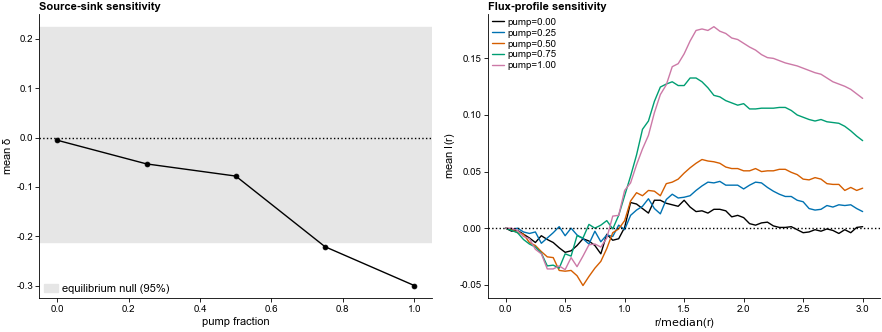

In [7]:
PUMP_VALUES = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
N_SWEEP = 30
mean_delta = np.empty(len(PUMP_VALUES))
mean_profiles = np.empty((len(PUMP_VALUES), len(RGRID)))

for i, pump in enumerate(PUMP_VALUES):
    deltas = np.array([
        birth_death_delta(simulate_source_sink(pump, seed=seed))[0]
        for seed in range(N_SWEEP)
    ])
    profiles = np.array([
        flux_profile(simulate_source_sink(pump, seed=seed))
        for seed in range(N_SWEEP)
    ])
    mean_delta[i] = np.nanmean(deltas)
    mean_profiles[i] = np.nanmean(profiles, axis=0)

fig, ax = plt.subplots(1, 2, figsize=(9.0, 3.5))
ax[0].axhspan(*null_delta_band, color="0.9", label="equilibrium null (95%)")
ax[0].plot(PUMP_VALUES, mean_delta, "o-")
ax[0].axhline(0, color="k", ls=":")
ax[0].set_xlabel("pump fraction")
ax[0].set_ylabel(r"mean $\delta$")
ax[0].set_title("Source-sink sensitivity")
ax[0].legend(fontsize=8)

for pump, profile in zip(PUMP_VALUES, mean_profiles):
    ax[1].plot(RGRID, profile, label=f"pump={pump:.2f}")
ax[1].axhline(0, color="k", ls=":")
ax[1].set_xlabel(r"$r / \mathrm{median}(r)$")
ax[1].set_ylabel(r"mean $I(r)$")
ax[1].set_title("Flux-profile sensitivity")
ax[1].legend(fontsize=7)
fig.tight_layout()
plt.show()


## 4. Apply the radial-current test to experimental data

For each condition, one $\delta$ value is calculated per independently analysed cell/focus. The condition mean is reported with a 95% Student-$t$ confidence interval and tested against zero using a two-sided one-sample $t$-test.

The grey bands in the figures are **simulation-derived equilibrium reference bands**, not confidence intervals for the experimental mean. The hypothesis test and the simulation band therefore answer related but distinct questions.


In [8]:
def load_trajectory_file(path: Path):
    """Load a whitespace-separated trajectory file as ``id, x, y, time``.

    Malformed files return ``None`` so a single bad input file does not stop the
    complete analysis. Additional columns are ignored.
    """
    try:
        data = np.genfromtxt(path)
    except (OSError, ValueError):
        return None

    if data.ndim != 2 or data.shape[1] < 4:
        return None
    return data[:, :4]


def iter_cells(condition: str):
    """Yield independently analysed cells/foci for one experimental condition.

    Rad51 files are treated as multi-focus fields and segmented with the same
    ``segment_foci`` routine as the main publication analysis. All other input
    files are treated as one cell/focus per file.
    """
    subdirectory, pattern, _ = DATASETS[condition]
    directory = DATA_ROOT / subdirectory
    files = sorted(directory.glob(pattern))
    files = [
        path for path in files
        if "2Foci" not in path.name and "2Cells" not in path.name
    ]

    for path in files:
        data = load_trajectory_file(path)
        if data is None:
            continue

        if condition in SEGMENT_DATASETS:
            for cell in segment_foci(data):
                if len(cell) >= MIN_TOTAL:
                    yield cell
        elif len(data) >= MIN_TOTAL:
            yield data


In [9]:
def summarize_delta_by_condition():
    """Calculate per-cell delta values and condition-level summary statistics."""
    results = {}
    print(f"{'condition':14s} {'n':>4s} {'mean delta':>11s} {'95% CI':>20s} {'p':>8s}")

    for condition in DATASETS:
        deltas = np.array([birth_death_delta(cell)[0] for cell in iter_cells(condition)])
        deltas = deltas[np.isfinite(deltas)]
        n = len(deltas)
        if n < 2:
            raise ValueError(f"{condition} has only {n} valid cell(s); at least two are required.")

        mean_delta = float(np.mean(deltas))
        se = float(np.std(deltas, ddof=1) / np.sqrt(n))
        ci = tuple(stats.t.interval(0.95, n - 1, loc=mean_delta, scale=se))
        pvalue = float(stats.ttest_1samp(deltas, 0.0).pvalue)
        results[condition] = {
            "n": n,
            "mean": mean_delta,
            "ci": ci,
            "pvalue": pvalue,
            "values": deltas,
        }
        print(
            f"{PRETTY_NAMES[condition]:14s} {n:4d} {mean_delta:+11.3f} "
            f"[{ci[0]:+.3f}, {ci[1]:+.3f}] {pvalue:8.3g}"
        )

    return results


experimental_delta = summarize_delta_by_condition()


condition         n  mean delta               95% CI        p
Rad52 (1 DSB)    26      +0.003 [-0.144, +0.150]    0.968
Rad52 (2 DSB)    14      -0.063 [-0.155, +0.028]    0.158
Rad52-SUMO       12      -0.063 [-0.203, +0.076]    0.341
Rad51            41      -0.049 [-0.134, +0.035]    0.245
Rfa1             23      +0.035 [-0.125, +0.194]    0.657


/var/folders/kp/rpw6x9gx71ncgf2hj3y5qc080000gn/T/ipykernel_22010/2331505136.py:27: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


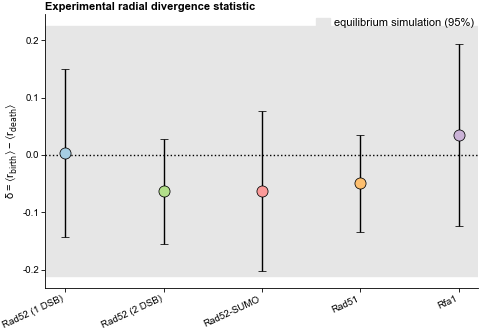

In [10]:
conditions = list(DATASETS)
colors = plt.cm.Paired(np.arange(0, 2 * len(conditions), 2))

fig, ax = plt.subplots(figsize=(5.0, 3.5))
ax.axhspan(*null_delta_band, color="0.9", label="equilibrium simulation (95%)")
for i, (condition, color) in enumerate(zip(conditions, colors)):
    result = experimental_delta[condition]
    lower = result["mean"] - result["ci"][0]
    upper = result["ci"][1] - result["mean"]
    ax.errorbar(
        i,
        result["mean"],
        yerr=[[lower], [upper]],
        fmt="o",
        ms=8,
        mec="k",
        ecolor="k",
        capsize=3,
        color=color,
    )

ax.axhline(0, color="k", ls=":")
ax.set_xticks(range(len(conditions)), [PRETTY_NAMES[c] for c in conditions], rotation=25, ha="right")
ax.set_ylabel(r"$\delta=\langle r_\mathrm{birth}\rangle-\langle r_\mathrm{death}\rangle$")
ax.set_title("Experimental radial divergence statistic")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## 5. Experimental radial profiles

The final panel retains the spatial information discarded by $\delta$. For each condition, profiles are calculated per cell and then averaged pointwise. The equilibrium simulation band is shown for reference.


/var/folders/kp/rpw6x9gx71ncgf2hj3y5qc080000gn/T/ipykernel_22010/1160901918.py:17: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


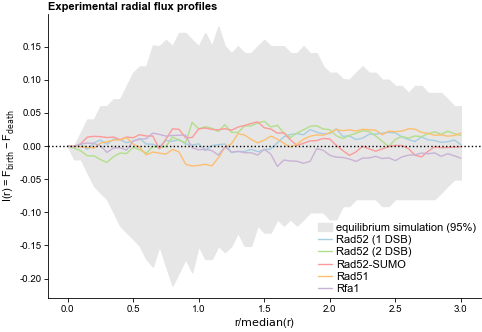

In [11]:
fig, ax = plt.subplots(figsize=(5.0, 3.5))
ax.fill_between(RGRID, profile_low, profile_high, color="0.9", label="equilibrium simulation (95%)")

for condition, color in zip(conditions, colors):
    profiles = np.array([flux_profile(cell) for cell in iter_cells(condition)])
    valid = np.isfinite(profiles).all(axis=1)
    profiles = profiles[valid]
    if len(profiles) == 0:
        continue
    ax.plot(RGRID, profiles.mean(axis=0), color=color, label=PRETTY_NAMES[condition])

ax.axhline(0, color="k", ls=":")
ax.set_xlabel(r"$r / \mathrm{median}(r)$")
ax.set_ylabel(r"$I(r)=F_\mathrm{birth}-F_\mathrm{death}$")
ax.set_title("Experimental radial flux profiles")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## Notes on interpretation

- A result compatible with zero does not prove detailed balance; it means this particular radial birth/death statistic does not detect a systematic source–sink imbalance.
- Track appearance/disappearance caused by the observation process can also alter birth/death locations. The equilibrium simulations therefore serve as an important calibration of the estimator under the same finite-track logic.
- The test is sensitive to radial divergence-like currents. A circulation with little or no radial divergence can remain invisible here; that complementary case is tested in `rotation_test.ipynb`.
